In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/student_success_expanded_balanced.csv')

In [ ]:
print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nMissing values per coloumn:\n", df.isnull().sum())
print("\nDescribe(numeric):\n", df.describe())

Shape: (951, 21)

Head:
    StudentID   Age  Gender    Country  AttendanceRate  StudyHoursPerWeek  \
0      10001  23.0    Male      India        0.924543           9.726927   
1      10002  31.0    Male   Pakistan        0.769927           7.454582   
2      10003  27.0    Male  Sri Lanka        0.995969           6.581002   
3      10004  24.0    Male      India        0.875446          11.977052   
4      10005  23.0  Female  Sri Lanka        0.803905           0.896958   

   SleepHours  InternetSpeedMbps DeviceType  PreviousGPA  ...  CommuteMins  \
0    6.165822          17.297479     Laptop     2.870025  ...    44.624160   
1    6.804910           9.786828     Laptop     3.091862  ...    54.964167   
2    9.503604           9.671157    Desktop     2.768614  ...    63.023413   
3    5.586163          17.520781     Laptop     2.134015  ...    74.240715   
4    9.422168          29.734222     Mobile     2.858312  ...    33.313836   

   Tutoring ParentalEducation LearningStyle Extra

In [ ]:
print("\nTarget value counts:\n", df['Result'].value_counts())


Target value counts:
 Result
Pass    476
Fail    475
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=['Result'])
y_raw = df['Result']

In [ ]:
X.head()

,StudentID,Age,Gender,Country,AttendanceRate,StudyHoursPerWeek,SleepHours,InternetSpeedMbps,DeviceType,PreviousGPA,PartTimeJobHours,CommuteMins,Tutoring,ParentalEducation,LearningStyle,ExtracurricularHours,QuizScore,AssignmentScore,MidtermScore,FinalScore
0,10001,23.0,Male,India,0.924543,9.726927,6.165822,17.297479,Laptop,2.870025,9.971490,44.624160,No,Masters,Reading,6.773810,79.483523,68.059875,61.875194,78.494855
1,10002,31.0,Male,Pakistan,0.769927,7.454582,6.804910,9.786828,Laptop,3.091862,9.711182,54.964167,Yes,Masters,Visual,0.000000,79.738937,68.226311,72.946944,90.050467
2,10003,27.0,Male,Sri Lanka,0.995969,6.581002,9.503604,9.671157,Desktop,2.768614,15.248218,63.023413,No,HighSchool,Kinesthetic,4.274718,80.970310,90.955478,80.861034,90.050236
3,10004,24.0,Male,India,0.875446,11.977052,5.586163,17.520781,Laptop,2.134015,0.000000,74.240715,Yes,HighSchool,Auditory,4.794347,94.394513,77.504459,96.472820,82.489804
4,10005,23.0,Female,Sri Lanka,0.803905,0.896958,9.422168,29.734222,Mobile,2.858312,12.340289,33.313836,No,HighSchool,Visual,5.867407,82.008211,72.318216,83.729495,66.509613


In [ ]:
y_raw.head()

,Result
0,Fail
1,Pass
2,Pass
3,Pass
4,Fail


In [ ]:
if y_raw.dtype =='object':
  y = y_raw.map({'Pass': 1, 'Fail': 0}).astype(int)

In [ ]:
y.head()

,Result
0,0
1,1
2,1
3,1
4,0


In [ ]:
numeric_cols =X.select_dtypes(include=['int64', 'float64', 'float32']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object','category']).columns.tolist()

In [ ]:
print("\nNumeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)


Numeric c: ['StudentID', 'Age', 'AttendanceRate', 'StudyHoursPerWeek', 'SleepHours', 'InternetSpeedMbps', 'PreviousGPA', 'PartTimeJobHours', 'CommuteMins', 'ExtracurricularHours', 'QuizScore', 'AssignmentScore', 'MidtermScore', 'FinalScore']

Categorical : ['Gender', 'Country', 'DeviceType', 'Tutoring', 'ParentalEducation', 'LearningStyle']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

In [ ]:
X.head()

,StudentID,Age,Gender,Country,AttendanceRate,StudyHoursPerWeek,SleepHours,InternetSpeedMbps,DeviceType,PreviousGPA,PartTimeJobHours,CommuteMins,Tutoring,ParentalEducation,LearningStyle,ExtracurricularHours,QuizScore,AssignmentScore,MidtermScore,FinalScore
0,10001,23.0,Male,India,0.924543,9.726927,6.165822,17.297479,Laptop,2.870025,9.971490,44.624160,No,Masters,Reading,6.773810,79.483523,68.059875,61.875194,78.494855
1,10002,31.0,Male,Pakistan,0.769927,7.454582,6.804910,9.786828,Laptop,3.091862,9.711182,54.964167,Yes,Masters,Visual,0.000000,79.738937,68.226311,72.946944,90.050467
2,10003,27.0,Male,Sri Lanka,0.995969,6.581002,9.503604,9.671157,Desktop,2.768614,15.248218,63.023413,No,HighSchool,Kinesthetic,4.274718,80.970310,90.955478,80.861034,90.050236
3,10004,24.0,Male,India,0.875446,11.977052,5.586163,17.520781,Laptop,2.134015,0.000000,74.240715,Yes,HighSchool,Auditory,4.794347,94.394513,77.504459,96.472820,82.489804
4,10005,23.0,Female,Sri Lanka,0.803905,0.896958,9.422168,29.734222,Mobile,2.858312,12.340289,33.313836,No,HighSchool,Visual,5.867407,82.008211,72.318216,83.729495,66.509613


In [ ]:
X_train_df, X_test_df, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [ ]:
X_train = preprocessor.fit_transform(X_train_df)
X_test = preprocessor.transform(X_test_df)

In [ ]:
print(X_train)
print(type(X_train))
print(X_train.shape)

[[ 1.6657043   0.02307467 -2.4570277  ...  0.          0.
   1.        ]
 [-1.15624468 -1.54113228 -0.09388359 ...  0.          0.
   1.        ]
 [ 0.05316203  0.17965637 -1.20205188 ...  0.          0.
   1.        ]
 ...
 [-0.08121649 -0.58513859  0.62506705 ...  0.          0.
   1.        ]
 [ 0.0152604   1.70924629  0.25953488 ...  1.          0.
   0.        ]
 [ 1.07650617 -0.20274111  1.4104542  ...  0.          0.
   1.        ]]
<class 'numpy.ndarray'>
(760, 34)


In [ ]:
num_features = X_train.shape[1]
print("\nProcessed feature count:", num_features)


Processed feature count: 34


In [ ]:
model = keras.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
print("\nModel Summary:")
model.summary()


Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
histpry=model.fit(
    X_train, y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=50,
    verbose=1
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5575 - loss: 0.6938 - val_accuracy: 0.6711 - val_loss: 0.6319
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7019 - loss: 0.5974 - val_accuracy: 0.7895 - val_loss: 0.5461
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8063 - loss: 0.5174 - val_accuracy: 0.8553 - val_loss: 0.4579
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8238 - loss: 0.4444 - val_accuracy: 0.8553 - val_loss: 0.3803
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8621 - loss: 0.3737 - val_accuracy: 0.8750 - val_loss: 0.3184
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8900 - loss: 0.2962 - val_accuracy: 0.8947 - val_loss: 0.2741
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9044 - loss: 0.2566 - val_accuracy: 0.8947 - val_loss: 0.2442
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9125 - loss: 0.2357 - val_accuracy: 0.9145 - val_loss

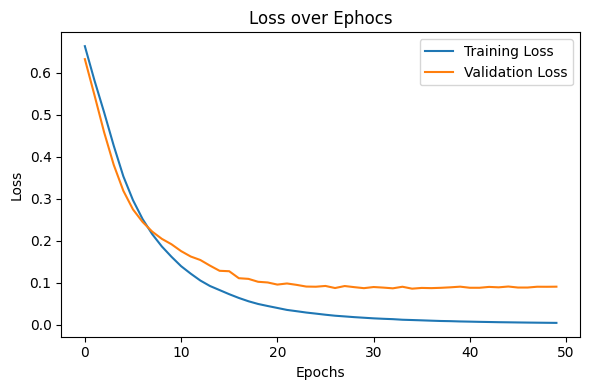

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(histpry.history['loss'], label='Training Loss')
plt.plot(histpry.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Ephocs')
plt.legend()
plt.tight_layout()
plt.show()

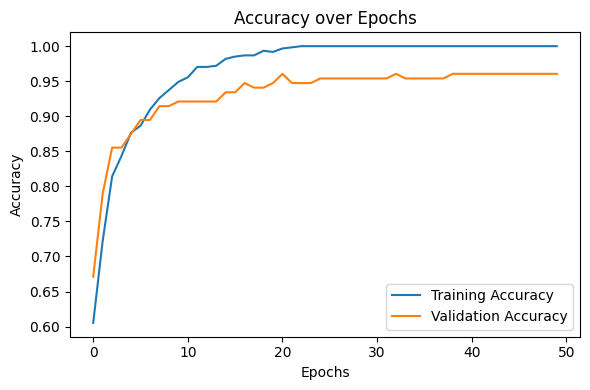

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(histpry.history['accuracy'], label='Training Accuracy')
plt.plot(histpry.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
tesr_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy: ",test_acc )

y_pred = (model.predict(X_test)>0.5).astype("int32")



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9292 - loss: 0.1959 
Test Accuracy:  0.9424083828926086
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


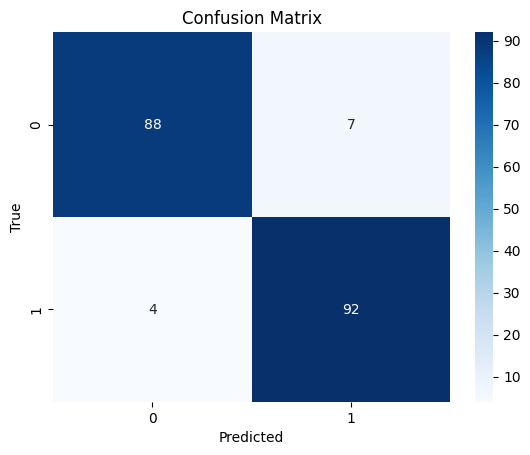

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',cmap="Blues")
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94        95
           1       0.93      0.96      0.94        96

    accuracy                           0.94       191
   macro avg       0.94      0.94      0.94       191
weighted avg       0.94      0.94      0.94       191

